In [1]:
## --- Bootstrap: Load shared environment setup ---

import os
from google.colab import drive

# Mount Drive only if not already mounted
if not os.path.ismount("/content/drive"):
    drive.mount('/content/drive')

# Path to your setup notebook
SETUP_NOTEBOOK = "/content/drive/MyDrive/ai_projects/setup_environment.ipynb"

# Run the setup notebook
%run $SETUP_NOTEBOOK

print("Environment initialized and ready.")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.0 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages wil

In [2]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END, START

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from dotenv import load_dotenv
env_path = "/content/drive/My Drive/ai_projects/.env"
load_dotenv(env_path)

True

In [5]:
class AgentState(TypedDict):
  messages:List[HumanMessage]

In [6]:
llm = ChatOpenAI(model="gpt-4o")

In [7]:
def process(state: AgentState)-> AgentState:
  response = llm.invoke(state["messages"])
  print(f'AI: {response.content}')
  return state

In [8]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)
agent = graph.compile()

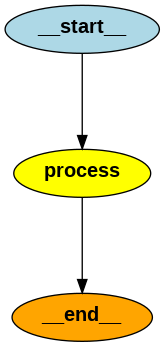

In [9]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(agent.get_graph().draw_png()))


In [10]:
user_input = input("Enter:")
while user_input != "exit":
  agent.invoke({
    "messages": [
        HumanMessage(content=user_input)
    ]
  })
  user_input = input("Enter:")

Enter:Hi what day is it?
AI: I'm sorry, but I don't have the ability to access real-time information. Please check your device or calendar for today's date.
Enter:ok sorry what can you tell me?
AI: No problem! I'm here to help with a wide range of topics. Whether you're looking for information on history, science, technology, entertainment, or advice on various subjects, feel free to ask. Let me know what you're interested in!
Enter:when was the war of 1812?
AI: The War of 1812 began on June 18, 1812, and ended on February 18, 1815, with the ratification of the Treaty of Ghent.
Enter:exit
